<a href="https://colab.research.google.com/github/angadpreeta/AI_ML_Project/blob/main/Assignment1_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

In [2]:
#Custom function to compute covariance matrix
def calc_cov_matrix(X):
  n_samples = X.shape[0]
  #center the data
  X_centered = X - np.mean(X, axis = 0)
  #compute covariance (X^T*X)/(n-1)
  cov = np.dot(X_centered.T,X_centered)/(n_samples-1)
  return cov

In [3]:
# Custom function to compute EigenValues and EigenVectors using power iteration
def perform_eigen_decomposition(A, num_eigen=10, max_iter=100, tol=1e-6):
    n = A.shape[0]
    EigenValues = []
    EigenVectors = np.zeros((n, num_eigen))

    # Make a copy of A to avoid modifying the original
    matrix = A.copy()

    for i in range(min(num_eigen, n)):
        # Initialize random vector
        v = np.random.rand(n)
        v = v / np.linalg.norm(v)

        for _ in range(max_iter):
            # Power iteration: v = Av / ||Av||
            v_new = np.dot(matrix, v)
            eigenvalue = np.linalg.norm(v_new)
            v_new = v_new / eigenvalue

            # Check convergence
            if np.linalg.norm(v_new - v) < tol:
                break
            v = v_new

            # Store eigenvalue and eigenvector
        EigenValues.append(eigenvalue)
        EigenVectors[:, i] = v_new

        # Deflate matrix: A = A - lambda * v * v^T
        matrix = matrix - eigenvalue * np.outer(v_new, v_new)

    return np.array(EigenValues), EigenVectors

In [4]:
# load MNIST dataset
(_,_), (X_test,_) = mnist.load_data()
#use first 2000 samples for test set
X = X_test[:2000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
#Preprocess: Scale to [0,1] and flatten
X = X.astype('float32')/255.0
X = X.reshape(X.shape[0],-1) #shape : (2000,784)

In [6]:
#Center the data
X_centered = X - np.mean(X, axis = 0)

In [7]:
#Compute Covariance matrix using custom function
cov_matrix = calc_cov_matrix(X_centered)

In [8]:
#Custom Eigen Decomposition (limit to top 500 for efficiency)
EigenValues,EigenVectors = perform_eigen_decomposition(cov_matrix, num_eigen=500)

In [9]:
#Sort EigenValue and EigenVector in descending order
idx = np.argsort(EigenValues)[::-1]
EigenValues = EigenValues[idx]
EigenVectors = EigenVectors[:,idx]

In [10]:
# Function to perform PCA and Reconstruction
def pca_reconstruct(X, EigenVectors, p):
  W = EigenVectors[:,:p]
  Z = np.dot(X, W)
  X_reconstructed = np.dot(Z, W.T)
  return X_reconstructed

In [11]:
#Perform PCA for different p values
p_values =[50,250,500]
reconstructions = {}
for p in p_values:
  if p<= len(EigenValues):  #Ensure p doesn't exceed available eigenvectors
    reconstructions[p] = pca_reconstruct(X_centered, EigenVectors, p)
    var_explained = np.sum(EigenValues[:p])/np.sum(EigenValues)
    print(f'Variance explained with p={p}: {var_explained:.3f}')
  else:
    print(f'p={p} exceeds available eigenvectors({len(EigenValues)})')

Variance explained with p=50: 0.826
Variance explained with p=250: 0.984
Variance explained with p=500: 1.000


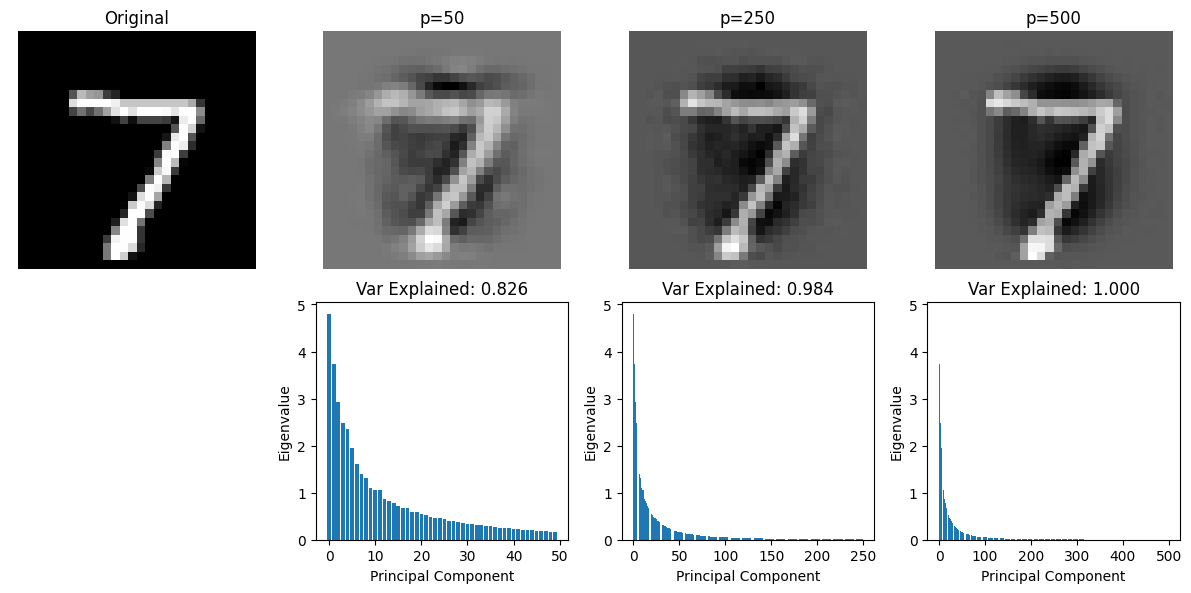

In [12]:
# Visualize results
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes[0, 0].imshow(X[0].reshape(28, 28), cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for i, p in enumerate(p_values):
    # Show reconstructed image
    axes[0, i+1].imshow(reconstructions[p][0].reshape(28, 28), cmap='gray')
    axes[0, i+1].set_title(f'p={p}')
    axes[0, i+1].axis('off')

    # Show variance explained
    var_explained = np.sum(EigenValues[:p]) / np.sum(EigenValues)
    cumulative_variance = np.cumsum(var_explained)
    axes[1, i+1].bar(range(p), EigenValues[:p])
    axes[1, i+1].set_title(f'Var Explained: {var_explained:.3f}')
    axes[1, i+1].set_xlabel('Principal Component')
    axes[1, i+1].set_ylabel('Eigenvalue')

# Hide empty subplot
axes[1, 0].axis('off')
plt.tight_layout()
plt.show()